# Week 6 — Fault Tolerance, Compression & Capstone

**Distributed Systems for Machine Learning**

---

A 1000-GPU run lasting weeks **will** see hardware failures — it's a statistical certainty, not an edge case. And the network is still the bottleneck. The final week covers the systems engineering that makes large runs *survive* and *go faster*:

- **Checkpointing**: how often to save, and the math of the optimal interval (Young/Daly).
- **Failure models** and **elastic** training that resizes the cluster on the fly.
- **Gradient compression**: quantization, **top-$k$ sparsification**, and the crucial **error-feedback** trick that makes lossy compression converge.
- **Capstone**: assemble everything into one simulated distributed training run with stragglers, a failure + recovery, compressed all-reduce, and a scaling report.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(6)
plt.rcParams["figure.figsize"]=(9,4.5); plt.rcParams["axes.grid"]=True

## 1. Checkpointing and the optimal interval

A checkpoint costs $C$ seconds to write. If we checkpoint every $\Delta$ seconds and the mean time between failures is $\text{MTBF}$, then per unit of useful work we waste: checkpoint overhead $\approx C/\Delta$, plus expected **rework** after a failure $\approx \Delta/(2\,\text{MTBF})$ (on average we lose half an interval). Minimizing the total gives the classic **Young/Daly** optimum:

$$\Delta^\star \approx \sqrt{2\,C\,\text{MTBF}}.$$

Checkpoint too often → waste time writing; too rarely → lose too much work on a crash. Let's plot the trade-off.

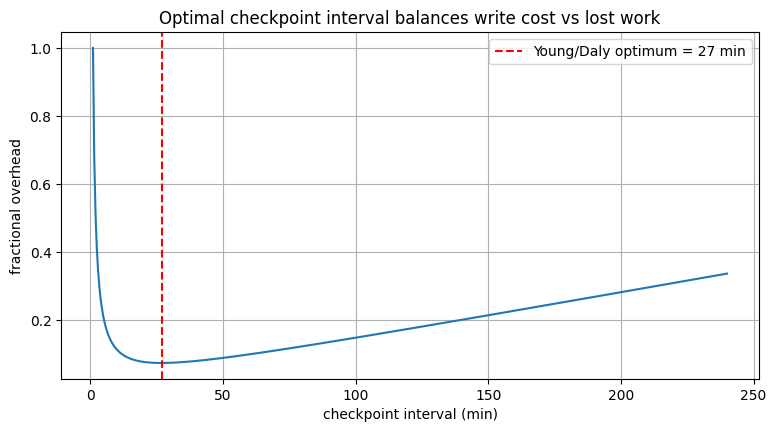

Optimal interval sqrt(2*C*MTBF) = 26.8 minutes


In [2]:
C = 60.0          # 60 s to write a checkpoint
MTBF = 6*3600.0   # a failure every ~6 hours on a big cluster

def overhead(delta, C, MTBF):
    return C/delta + delta/(2*MTBF)

deltas=np.linspace(60, 4*3600, 500)
ov=[overhead(d,C,MTBF) for d in deltas]
opt=np.sqrt(2*C*MTBF)
plt.plot(deltas/60, ov)
plt.axvline(opt/60, color="red", ls="--", label=f"Young/Daly optimum = {opt/60:.0f} min")
plt.xlabel("checkpoint interval (min)"); plt.ylabel("fractional overhead")
plt.title("Optimal checkpoint interval balances write cost vs lost work"); plt.legend(); plt.show()
print(f"Optimal interval sqrt(2*C*MTBF) = {opt/60:.1f} minutes")

## 2. Failure & recovery simulation

We model a run as a sequence of steps. Failures arrive as a Poisson process with rate $1/\text{MTBF}$. On failure, training rolls back to the **last checkpoint** and re-does the lost steps. We track *useful progress* vs *wall-clock* with and without checkpointing.

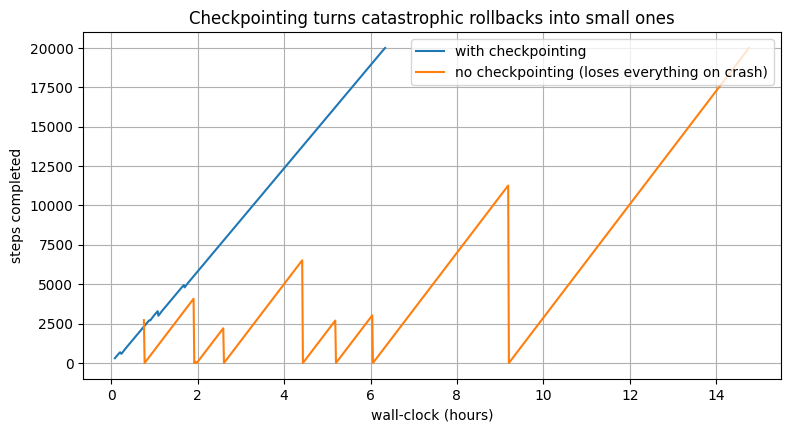

In [3]:
def simulate_run(total_steps=20000, step_time=1.0, ckpt_interval_steps=300,
                 ckpt_cost=30.0, mtbf_steps=4000, seed=0):
    rng=np.random.default_rng(seed)
    wall=0.0; done=0; last_ckpt=0
    progress=[]; walls=[]
    while done < total_steps:
        # steps until next failure (geometric ~ exponential)
        steps_to_fail = rng.geometric(1/mtbf_steps)
        steps_to_ckpt = ckpt_interval_steps - (done-last_ckpt)
        run = min(steps_to_fail, steps_to_ckpt, total_steps-done)
        wall += run*step_time; done += run
        progress.append(done); walls.append(wall)
        if done-last_ckpt >= ckpt_interval_steps:
            wall += ckpt_cost; last_ckpt=done           # take checkpoint
        if run==steps_to_fail and done<total_steps:
            wall += 60.0                                # restart overhead
            done = last_ckpt                            # roll back!
            progress.append(done); walls.append(wall)
    return np.array(walls), np.array(progress)

w_ck,p_ck = simulate_run(ckpt_interval_steps=300)
w_no,p_no = simulate_run(ckpt_interval_steps=10**9)  # effectively no checkpoint
plt.plot(w_ck/3600, p_ck, label="with checkpointing")
plt.plot(w_no/3600, p_no, label="no checkpointing (loses everything on crash)")
plt.xlabel("wall-clock (hours)"); plt.ylabel("steps completed")
plt.title("Checkpointing turns catastrophic rollbacks into small ones"); plt.legend(); plt.show()

**Elastic training** goes further: instead of halting when a worker dies, the job *continues* with fewer workers (re-sharding data and rebuilding the communication ring) and re-absorbs replacements when they come back. This needs (a) a membership protocol, (b) re-deriving the collective topology, and (c) keeping the global batch sensible as $P$ changes. The all-reduce/all-gather primitives from Week 2 are exactly what must be rebuilt on a membership change.

## 3. Gradient compression

Communication is the bottleneck; gradients are *compressible*. Two families:

- **Quantization**: send fewer bits per value (e.g. 8-bit, or even 1-bit SignSGD).
- **Sparsification**: send only the **top-$k$** largest-magnitude entries; zero the rest.

Both are *lossy* and naively bias the optimizer. The fix is **error feedback**: keep the residual (what you *didn't* send) in a local accumulator and add it back next step, so no gradient information is permanently lost — it's just delayed. We implement top-$k$ + error feedback and show it recovers full-precision convergence at a fraction of the bytes.

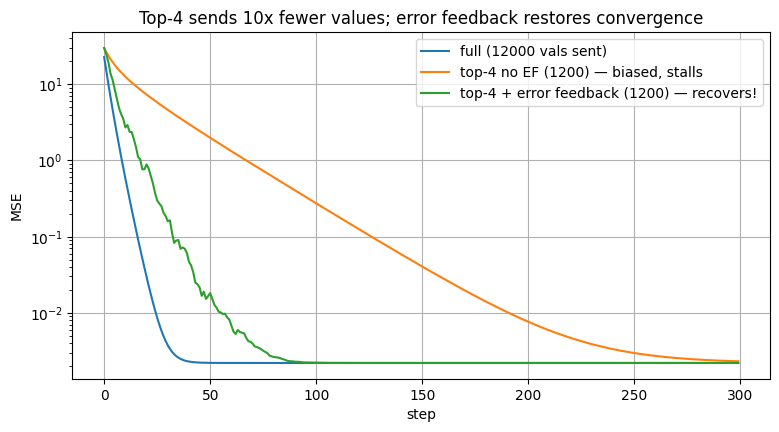

In [4]:
B,d=600,40
X=np.random.randn(B,d); w_true=np.random.randn(d); y=X@w_true+0.05*np.random.randn(B)
def grad(w): r=X@w-y; return (2.0/B)*(X.T@r)
def mse(w): r=X@w-y; return float(np.mean(r*r))

def topk(v,k):
    out=np.zeros_like(v)
    idx=np.argpartition(np.abs(v),-k)[-k:]
    out[idx]=v[idx]; return out

def train(compress=None, k=4, error_feedback=False, steps=300, lr=0.1):
    w=np.zeros(d); mem=np.zeros(d); L=[]; sent=0
    for t in range(steps):
        g=grad(w)
        if compress=="topk":
            g_in = g+mem if error_feedback else g
            g_c = topk(g_in,k)
            if error_feedback: mem = g_in - g_c   # keep the residual
            sent += k
            g=g_c
        else:
            sent += d
        w-=lr*g; L.append(mse(w))
    return L, sent

L_full,s_full = train()
L_topk,s_tk   = train(compress="topk",k=4,error_feedback=False)
L_ef,s_ef     = train(compress="topk",k=4,error_feedback=True)
plt.plot(L_full,label=f"full ({s_full} vals sent)")
plt.plot(L_topk,label=f"top-4 no EF ({s_tk}) — biased, stalls")
plt.plot(L_ef,label=f"top-4 + error feedback ({s_ef}) — recovers!")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE"); plt.legend()
plt.title(f"Top-4 sends {d//4}x fewer values; error feedback restores convergence"); plt.show()

The plot makes the lesson vivid: top-$k$ *without* error feedback plateaus (the dropped gradient mass is lost forever), while top-$k$ *with* error feedback tracks full precision — at $10\times$ less communication here. This is the core idea behind Deep Gradient Compression and 1-bit Adam.

## 4. Capstone — a complete simulated distributed run

We now assemble the whole course into one trainer that has:
- **Data parallelism** with **ring all-reduce** cost accounting (Weeks 2–3),
- **gradient compression** with error feedback (this week),
- a **straggler** model (Week 4),
- a **checkpoint + failure + rollback** (this week),
- and a final **scaling & cost report**.


Final MSE        : 0.00220
Failures handled : 0 (rolled back to checkpoint each time)
Comm bytes/worker: 0.04 MB  (top-k compressed)
Simulated wall   : 456 units


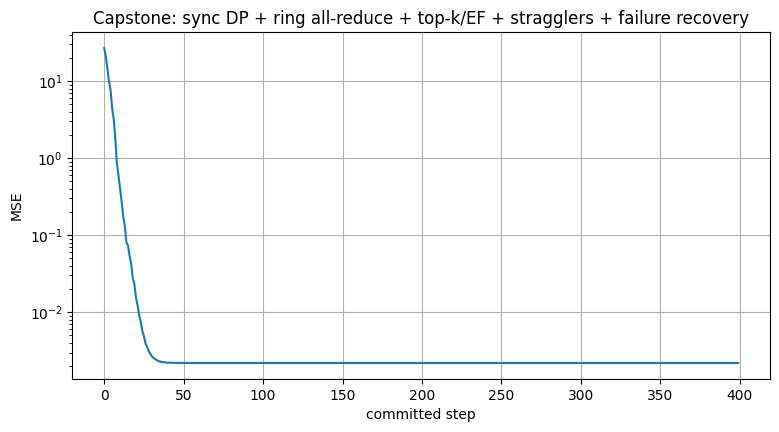

In [5]:
def ring_allreduce_bytes_per_worker(n_vals, P):
    return 2*(P-1)/P * n_vals * 8   # float64

def capstone(P=8, steps=400, lr=0.1, k=8, ckpt_every=120,
             mtbf=250, straggler_p=0.15, seed=1):
    rng=np.random.default_rng(seed)
    w=np.zeros(d); mem=np.zeros(d)
    last_ckpt_w=w.copy(); last_ckpt_step=0
    L=[]; comm_bytes=0; wall=0.0; failures=0
    t=0
    while t<steps:
        # ---- per-worker gradients on shards, then average (sync DP) ----
        idx=rng.integers(0,B,size=P*16)
        shards=np.array_split(idx,P)
        g=np.mean([grad(w) for _ in shards],axis=0)  # toy: same problem
        # ---- compress with error feedback ----
        g_in=g+mem; g_c=topk(g_in,k); mem=g_in-g_c
        comm_bytes += ring_allreduce_bytes_per_worker(k,P)  # only k values
        # ---- straggler: slowest worker inflates step time ----
        step_t = max(rng.random(P)*(3 if rng.random()<straggler_p else 1))
        wall += step_t
        w -= lr*g_c; t+=1; L.append(mse(w))
        # ---- checkpoint ----
        if t-last_ckpt_step>=ckpt_every:
            last_ckpt_w=w.copy(); last_ckpt_step=t; wall+=5.0
        # ---- random failure -> rollback ----
        if rng.random() < 1/mtbf:
            failures+=1; wall+=20.0
            w=last_ckpt_w.copy(); t=last_ckpt_step
    return L, comm_bytes, wall, failures

L,cb,wall,fails = capstone()
print(f"Final MSE        : {L[-1]:.5f}")
print(f"Failures handled : {fails} (rolled back to checkpoint each time)")
print(f"Comm bytes/worker: {cb/2**20:.2f} MB  (top-k compressed)")
print(f"Simulated wall   : {wall:.0f} units")
plt.plot(L); plt.yscale("log"); plt.xlabel("committed step"); plt.ylabel("MSE")
plt.title("Capstone: sync DP + ring all-reduce + top-k/EF + stragglers + failure recovery")
plt.show()

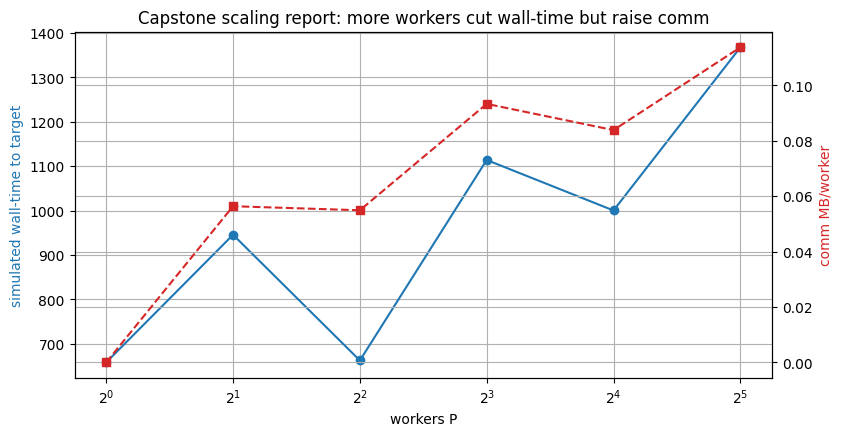

You have built a distributed ML training system from first principles. 


In [6]:
# Scaling report: time-to-target vs P, holding everything else fixed
target=0.01
def steps_to_target(P):
    L,cb,wall,_=capstone(P=P, steps=600, seed=2)
    for i,v in enumerate(L):
        if v<target: return i+1, cb, wall
    return len(L), cb, wall

Ps=[1,2,4,8,16,32]
res=[steps_to_target(p) for p in Ps]
walls=[r[2] for r in res]; comm=[r[1]/2**20 for r in res]
fig,ax1=plt.subplots()
ax1.plot(Ps,walls,"o-",color="tab:blue"); ax1.set_xlabel("workers P")
ax1.set_ylabel("simulated wall-time to target",color="tab:blue"); ax1.set_xscale("log",base=2)
ax2=ax1.twinx(); ax2.plot(Ps,comm,"s--",color="tab:red")
ax2.set_ylabel("comm MB/worker",color="tab:red")
plt.title("Capstone scaling report: more workers cut wall-time but raise comm"); plt.show()
print("You have built a distributed ML training system from first principles. ")

## Exercises (Capstone extensions)

1. **Elastic resize.** Add a membership change: at a random step, drop 2 workers and rebuild the ring with the new $P$. Show the run continues and the all-reduce cost updates.
2. **Async variant.** Swap the synchronous average for the async parameter-server update from Week 4 (with bounded staleness) and compare time-to-target under heavy stragglers.
3. **Compression sweep.** Sweep $k\in\{1,2,4,8,d\}$ and 8-bit quantization; plot the Pareto frontier of *time-to-accuracy* vs *bytes sent*. Where is the knee?
4. **Right checkpoint interval.** Use the Young/Daly formula with your simulated MTBF and checkpoint cost to pick `ckpt_every`, then verify empirically it minimizes wall-time.
5. **Full report.** Produce a one-page markdown report for a hypothetical 64-GPU run: chosen parallelism strategy (tie back to Week 5's 3D parallelism), collective algorithm, compression scheme, checkpoint policy, and expected scaling efficiency. Justify each choice with the cost models from this course.
